In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display

# ====== НАСТРОЙКИ ======
DATA_PATH = Path("../news_data/0101202-23042026_merged_newsdata.parquet")
TOP_N_EXAMPLES = 5
SHORT_TEXT_THRESHOLD = 30  # слов

# ====== ЗАГРУЗКА ======
if DATA_PATH.suffix.lower() == ".parquet":
    df = pd.read_parquet(DATA_PATH)
elif DATA_PATH.suffix.lower() == ".csv":
    df = pd.read_csv(DATA_PATH)
else:
    raise ValueError(f"Неподдерживаемый формат файла: {DATA_PATH.suffix}")

print(f"Файл: {DATA_PATH.resolve()}")
print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} колонок\n")

print("Колонки:")
print(df.columns.tolist())

print("\nПервые строки:")
display(df.head(3))

Файл: C:\Users\skuts\vibecode_projects\news_data\0101202-23042026_merged_newsdata.parquet
Размер датасета: 146620 строк, 9 колонок

Колонки:
['source', 'url', 'archive_date', 'published_at', 'title', 'text', 'category_raw', 'category_norm', 'collected_at']

Первые строки:


,source,url,archive_date,published_at,title,text,category_raw,category_norm,collected_at
0,lenta.ru,https://lenta.ru/news/2025/01/01/auto/,2025-01-01,2025-01-01 00:00:00,"Рост акцизов на топливо, увеличение утильсбора...",В России с 1 января 2025 года вступает в силу ...,Россия,Россия,2026-04-24T08:54:39+00:00
1,lenta.ru,https://lenta.ru/news/2025/01/01/v-rossii-stal...,2025-01-01,2025-01-01 00:02:00,В России стало дороже развестись,В России кратно увеличился размер госпошлины з...,Россия,Россия,2026-04-24T08:54:39+00:00
2,lenta.ru,https://lenta.ru/news/2025/01/01/v-rossii-s-1-...,2025-01-01,2025-01-01 01:23:00,В России с 1 января повысили штрафы за нарушен...,В России с 1 января повысили штрафы за превыше...,Россия,Россия,2026-04-24T08:54:39+00:00


In [2]:
# ====== ПРИВЕДЕНИЕ ТИПОВ ======
if "published_at" in df.columns:
    df["published_at"] = pd.to_datetime(df["published_at"], errors="coerce")

if "text" in df.columns:
    df["text_len_chars"] = df["text"].fillna("").astype(str).str.len()
    df["text_len_words"] = df["text"].fillna("").astype(str).str.split().str.len()

# ====== ОПРЕДЕЛЕНИЕ КОЛОНКИ РУБРИК ======
category_col = next(
    (c for c in ["category_norm", "category_raw", "topic"] if c in df.columns),
    None
)

print("--- Общая информация ---")
df.info()

print("\n--- Describe (all columns) ---")
display(df.describe(include="all").T)

print("\n--- Пропуски ---")
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2)
}).sort_values(["missing_count", "missing_pct"], ascending=False)
display(missing)

print("\n--- Дубликаты ---")
dup_full = df.duplicated().sum()
print(f"Полные дубликаты строк: {dup_full}")

if "url" in df.columns:
    dup_url = df["url"].duplicated().sum()
    print(f"Дубликаты по url: {dup_url}")

if {"title", "text"}.issubset(df.columns):
    dup_title_text = df.duplicated(subset=["title", "text"]).sum()
    print(f'Дубликаты по ["title", "text"]: {dup_title_text}')

if "text_len_words" in df.columns:
    short_texts = (df["text_len_words"] < SHORT_TEXT_THRESHOLD).sum()
    print(f"Текстов короче {SHORT_TEXT_THRESHOLD} слов: {short_texts} "
          f"({short_texts / len(df) * 100:.2f}%)")

--- Общая информация ---
<class 'pandas.DataFrame'>
RangeIndex: 146620 entries, 0 to 146619
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   source          146620 non-null  str           
 1   url             146620 non-null  str           
 2   archive_date    146620 non-null  str           
 3   published_at    146620 non-null  datetime64[us]
 4   title           146620 non-null  str           
 5   text            146620 non-null  str           
 6   category_raw    146620 non-null  str           
 7   category_norm   146620 non-null  str           
 8   collected_at    146620 non-null  str           
 9   text_len_chars  146620 non-null  int64         
 10  text_len_words  146620 non-null  int64         
dtypes: datetime64[us](1), int64(2), str(8)
memory usage: 693.3 MB

--- Describe (all columns) ---


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
source,146620,1,lenta.ru,146620,NaN,NaN,NaN,NaN,NaN,NaN,NaN
url,146620,146620,https://lenta.ru/news/2025/01/01/auto/,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
archive_date,146620,478,2025-06-19,490,NaN,NaN,NaN,NaN,NaN,NaN,NaN
published_at,146620,NaN,NaN,NaN,2025-08-25 03:38:33.366252,2025-01-01 00:00:00,2025-04-27 07:23:15,2025-08-21 19:50:00,2025-12-17 18:12:15,2026-04-23 23:58:00,NaN
title,146620,144236,Минобороны раскрыло подробности о ночных удара...,38,NaN,NaN,NaN,NaN,NaN,NaN,NaN
text,146620,146619,Сообщение о рекламе в Лос-Анджелесе с фото Бор...,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category_raw,146620,6,Мир,45383,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category_norm,146620,6,Мир,45383,NaN,NaN,NaN,NaN,NaN,NaN,NaN
collected_at,146620,13710,2026-04-24T09:16:54+00:00,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
text_len_chars,146620.0,NaN,NaN,NaN,2536.206929,397.0,1696.0,2073.0,2781.0,55620.0,1694.131506



--- Пропуски ---


,missing_count,missing_pct
source,0,0.0
url,0,0.0
archive_date,0,0.0
published_at,0,0.0
title,0,0.0
text,0,0.0
category_raw,0,0.0
category_norm,0,0.0
collected_at,0,0.0
text_len_chars,0,0.0



--- Дубликаты ---
Полные дубликаты строк: 0
Дубликаты по url: 0
Дубликаты по ["title", "text"]: 1
Текстов короче 30 слов: 0 (0.00%)


--- Даты ---
Минимальная дата: 2025-01-01 00:00:00
Максимальная дата: 2026-04-23 23:58:00
Не распарсилось дат: 0

--- Новости по месяцам ---


,count
year_month,
2025-01,8623
2025-02,9415
2025-03,10044
2025-04,9859
2025-05,9480
2025-06,9652
2025-07,9573
2025-08,9367
2025-09,9446


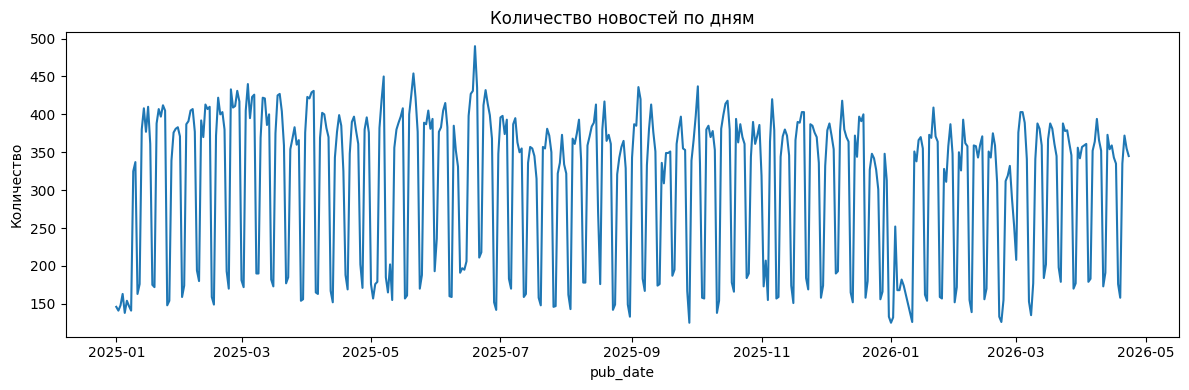

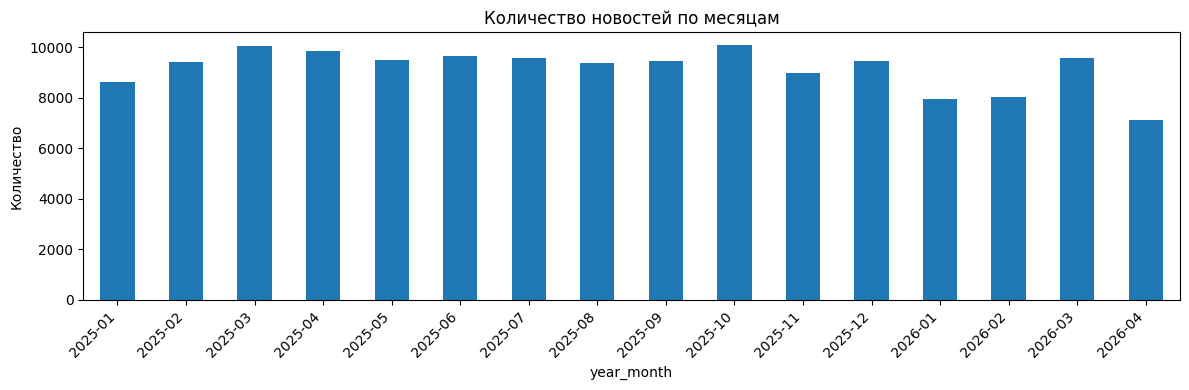

In [3]:
if "published_at" in df.columns:
    print("--- Даты ---")
    print("Минимальная дата:", df["published_at"].min())
    print("Максимальная дата:", df["published_at"].max())
    print("Не распарсилось дат:", df["published_at"].isna().sum())

    tmp_dates = df.dropna(subset=["published_at"]).copy()
    tmp_dates["pub_date"] = tmp_dates["published_at"].dt.date
    tmp_dates["year_month"] = tmp_dates["published_at"].dt.to_period("M").astype(str)

    print("\n--- Новости по месяцам ---")
    month_counts = tmp_dates["year_month"].value_counts().sort_index()
    display(month_counts.to_frame("count"))

    plt.figure(figsize=(12, 4))
    tmp_dates["pub_date"].value_counts().sort_index().plot(kind="line")
    plt.title("Количество новостей по дням")
    plt.ylabel("Количество")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 4))
    month_counts.plot(kind="bar")
    plt.title("Количество новостей по месяцам")
    plt.ylabel("Количество")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("Колонка published_at не найдена.")

--- Распределение по рубрикам (category_norm) ---


,count,share_pct
category_norm,,
Мир,45383,30.95
Россия,41352,28.20
Экономика,32112,21.90
Наука и техника,10168,6.93
Спорт,9869,6.73
Культура,7736,5.28


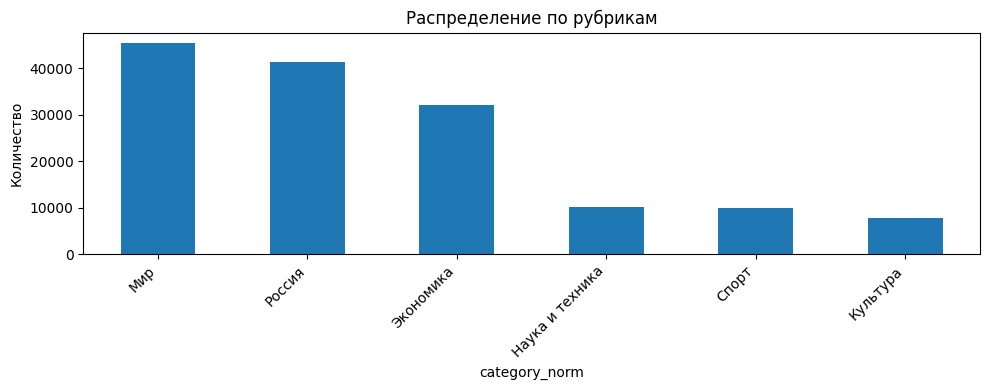


--- Рубрика × месяц ---


category_norm,Культура,Мир,Наука и техника,Россия,Спорт,Экономика
year_month,,,,,,
2025-01,442,2847,457,2392,625,1860
2025-02,559,2910,547,2601,653,2145
2025-03,526,3004,688,3008,670,2148
2025-04,563,2694,730,3081,683,2108
2025-05,462,2939,631,3081,633,1734
2025-06,501,3016,609,2910,601,2015
2025-07,511,2496,672,3037,634,2223
2025-08,621,2876,599,2758,585,1928
2025-09,526,2696,720,2773,587,2144



--- Распределение по источникам ---


,count,share_pct
source,,
lenta.ru,146620,100.0


In [4]:
if category_col:
    print(f"--- Распределение по рубрикам ({category_col}) ---")
    cat_counts = df[category_col].fillna("MISSING").value_counts()
    cat_summary = pd.DataFrame({
        "count": cat_counts,
        "share_pct": (cat_counts / len(df) * 100).round(2)
    })
    display(cat_summary)

    plt.figure(figsize=(10, 4))
    cat_counts.plot(kind="bar")
    plt.title("Распределение по рубрикам")
    plt.ylabel("Количество")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    if "published_at" in df.columns and df["published_at"].notna().any():
        tmp_cat = df.dropna(subset=["published_at"]).copy()
        tmp_cat["year_month"] = tmp_cat["published_at"].dt.to_period("M").astype(str)

        print("\n--- Рубрика × месяц ---")
        pivot_month_cat = pd.crosstab(tmp_cat["year_month"], tmp_cat[category_col])
        display(pivot_month_cat)
else:
    print("Колонка рубрик не найдена.")

if "source" in df.columns:
    print("\n--- Распределение по источникам ---")
    source_counts = df["source"].fillna("MISSING").value_counts()
    source_summary = pd.DataFrame({
        "count": source_counts,
        "share_pct": (source_counts / len(df) * 100).round(2)
    })
    display(source_summary)

--- Длины текстов ---


,count,mean,std,min,25%,50%,75%,max
text_len_chars,146620.0,2536.206929,1694.131506,397.0,1696.0,2073.0,2781.0,55620.0
text_len_words,146620.0,351.573980,235.043445,51.0,236.0,288.0,384.0,7977.0


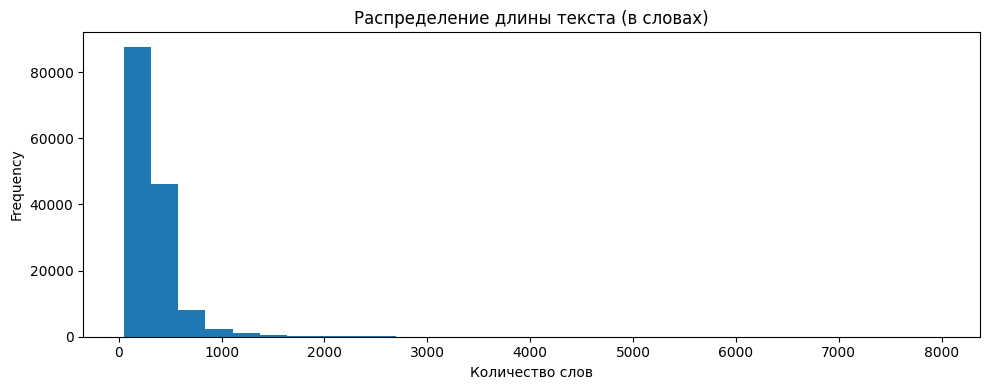


--- Длина текста по рубрикам ---


,count,mean,median,min,max
category_norm,,,,,
Мир,45383,310.00,264.0,51,6857
Россия,41352,363.59,276.0,86,7977
Экономика,32112,408.20,354.0,106,4174
Наука и техника,10168,432.99,420.0,116,2743
Спорт,9869,275.96,254.0,125,1814
Культура,7736,285.62,258.0,117,4242



--- Примеры самых коротких текстов ---


,published_at,category_norm,title,text_len_words,url
134217,2026-03-15 02:20:00,Мир,Стало известно об истощении запасов ракет-пере...,51,https://lenta.ru/news/2026/03/15/stalo-izvestn...
100918,2025-11-19 11:04:00,Мир,МИД Польши вызвал временного поверенного в дел...,60,https://lenta.ru/news/2025/11/19/mid-polshi-vy...
122110,2026-02-02 12:11:00,Россия,В Москве и Санкт-Петербурге пройдут концерты п...,86,https://lenta.ru/news/2026/02/02/v-moskve-i-sa...
51117,2025-06-12 14:02:00,Мир,В Сербии устроили автопробег в честь Дня России,95,https://lenta.ru/news/2025/06/12/v-serbii-ustr...
27095,2025-03-28 11:45:00,Россия,Пылающую после удара ВСУ газоизмерительную ста...,97,https://lenta.ru/news/2025/03/28/pylayuschuyu-...



--- Примеры самых длинных текстов ---


,published_at,category_norm,title,text_len_words,url
58989,2025-07-07 00:10:00,Россия,"Рождество Иоанна Предтечи в 2025 году: суть, и...",7977,https://lenta.ru/news/2025/07/07/rozhdestvo-io...
102884,2025-11-25 16:29:00,Мир,"«У вас были шансы, ребята». На Западе заявили ...",6857,https://lenta.ru/news/2025/11/25/abu-dabi/
104990,2025-12-02 15:30:00,Мир,«Важный день для мира». Доверенные лица Трампа...,6828,https://lenta.ru/news/2025/12/02/witkoff-kushner/
105411,2025-12-03 17:26:00,Мир,«Есть три столпа». Кремль назвал главные услов...,6656,https://lenta.ru/news/2025/12/03/uslovia/
102897,2025-11-25 19:21:00,Мир,Из мирного плана по Украине исчез «деликатный ...,6364,https://lenta.ru/news/2025/11/25/land/



--- Краткий вывод ---
Всего новостей: 146,620
Число рубрик: 6
Размер наименьшего класса: 7736
Размер наибольшего класса: 45383
Период покрытия: 2025-01-01 00:00:00 — 2026-04-23 23:58:00
Медианная длина текста: 288 слов
Коротких текстов (< 30 слов): 0 (0.00%)

Что проверить перед моделированием:
1. Удалить/отфильтровать пустые и слишком короткие тексты.
2. Проверить и при необходимости убрать дубликаты по url или title+text.
3. Оценить дисбаланс классов и решить, нужен ли балансинг/weights.
4. Убедиться, что даты и рубрики распарсились корректно.
5. Сделать train/valid/test split со stratify по рубрике.


In [5]:
if "text_len_chars" in df.columns:
    print("--- Длины текстов ---")
    stats = df[["text_len_chars", "text_len_words"]].describe().T
    display(stats)

    plt.figure(figsize=(10, 4))
    df["text_len_words"].dropna().plot(kind="hist", bins=30)
    plt.title("Распределение длины текста (в словах)")
    plt.xlabel("Количество слов")
    plt.tight_layout()
    plt.show()

    if category_col:
        print("\n--- Длина текста по рубрикам ---")
        text_by_cat = (
            df.groupby(category_col)["text_len_words"]
            .agg(["count", "mean", "median", "min", "max"])
            .sort_values("count", ascending=False)
            .round(2)
        )
        display(text_by_cat)

print("\n--- Примеры самых коротких текстов ---")
if {"title", "text_len_words"}.issubset(df.columns):
    cols = [c for c in ["published_at", category_col, "title", "text_len_words", "url"] if c and c in df.columns]
    display(df.sort_values("text_len_words").head(TOP_N_EXAMPLES)[cols])

print("\n--- Примеры самых длинных текстов ---")
if {"title", "text_len_words"}.issubset(df.columns):
    cols = [c for c in ["published_at", category_col, "title", "text_len_words", "url"] if c and c in df.columns]
    display(df.sort_values("text_len_words", ascending=False).head(TOP_N_EXAMPLES)[cols])

print("\n--- Краткий вывод ---")
print(f"Всего новостей: {len(df):,}")

if category_col:
    n_classes = df[category_col].nunique(dropna=True)
    min_class = df[category_col].value_counts(dropna=True).min()
    max_class = df[category_col].value_counts(dropna=True).max()
    print(f"Число рубрик: {n_classes}")
    print(f"Размер наименьшего класса: {min_class}")
    print(f"Размер наибольшего класса: {max_class}")

if "published_at" in df.columns:
    print(f"Период покрытия: {df['published_at'].min()} — {df['published_at'].max()}")

if "text_len_words" in df.columns:
    print(f"Медианная длина текста: {df['text_len_words'].median():.0f} слов")
    short_texts = (df["text_len_words"] < SHORT_TEXT_THRESHOLD).sum()
    print(f"Коротких текстов (< {SHORT_TEXT_THRESHOLD} слов): {short_texts} "
          f"({short_texts / len(df) * 100:.2f}%)")

print("\nЧто проверить перед моделированием:")
print("1. Удалить/отфильтровать пустые и слишком короткие тексты.")
print("2. Проверить и при необходимости убрать дубликаты по url или title+text.")
print("3. Оценить дисбаланс классов и решить, нужен ли балансинг/weights.")
print("4. Убедиться, что даты и рубрики распарсились корректно.")
print("5. Сделать train/valid/test split со stratify по рубрике.")

In [6]:
# ====== ОЧИСТКА ПЕРЕД МОДЕЛИРОВАНИЕМ ======

df_model = df.copy()
initial_rows = len(df_model)

print(f"Строк в исходном датасете: {initial_rows:,}")

# 1. Выбираем колонку рубрик
category_col = next(
    (c for c in ["category_norm", "category_raw", "topic"] if c in df_model.columns),
    None
)

if category_col is None:
    raise ValueError("Не найдена колонка с рубриками: category_norm / category_raw / topic")

# 2. Удаляем полные дубликаты
before = len(df_model)
df_model = df_model.drop_duplicates()
removed = before - len(df_model)
print(f"Удалено полных дубликатов: {removed:,}")

# 3. Удаляем дубликаты по url, если url есть
if "url" in df_model.columns:
    before = len(df_model)
    df_model = df_model.drop_duplicates(subset=["url"])
    removed = before - len(df_model)
    print(f"Удалено дубликатов по url: {removed:,}")

# 4. Удаляем дубликаты по title + text, если обе колонки есть
if {"title", "text"}.issubset(df_model.columns):
    before = len(df_model)
    df_model = df_model.drop_duplicates(subset=["title", "text"])
    removed = before - len(df_model)
    print(f'Удалено дубликатов по ["title", "text"]: {removed:,}')

# 5. Удаляем строки без текста
if "text" in df_model.columns:
    before = len(df_model)
    df_model["text"] = df_model["text"].fillna("").astype(str).str.strip()
    df_model = df_model[df_model["text"] != ""]
    removed = before - len(df_model)
    print(f"Удалено строк без текста: {removed:,}")

# 6. Удаляем строки без заголовка
if "title" in df_model.columns:
    before = len(df_model)
    df_model["title"] = df_model["title"].fillna("").astype(str).str.strip()
    df_model = df_model[df_model["title"] != ""]
    removed = before - len(df_model)
    print(f"Удалено строк без заголовка: {removed:,}")

# 7. Удаляем строки без рубрики
before = len(df_model)
df_model[category_col] = df_model[category_col].fillna("").astype(str).str.strip()
df_model = df_model[df_model[category_col] != ""]
removed = before - len(df_model)
print(f"Удалено строк без рубрики ({category_col}): {removed:,}")

# 8. Удаляем строки без даты, если дата важна
if "published_at" in df_model.columns:
    before = len(df_model)
    df_model = df_model[df_model["published_at"].notna()]
    removed = before - len(df_model)
    print(f"Удалено строк без published_at: {removed:,}")

# 9. Пересчитываем длины текстов
df_model["text_len_chars"] = df_model["text"].astype(str).str.len()
df_model["text_len_words"] = df_model["text"].astype(str).str.split().str.len()

# 10. Удаляем слишком короткие тексты
before = len(df_model)
df_model = df_model[df_model["text_len_words"] >= SHORT_TEXT_THRESHOLD]
removed = before - len(df_model)
print(f"Удалено слишком коротких текстов (< {SHORT_TEXT_THRESHOLD} слов): {removed:,}")

# 11. Сбрасываем индекс
df_model = df_model.reset_index(drop=True)

print(f"\nСтрок после очистки: {len(df_model):,}")
print(f"Удалено всего: {initial_rows - len(df_model):,} "
      f"({(initial_rows - len(df_model)) / initial_rows * 100:.2f}%)")

print("\n--- Остаток по рубрикам ---")
class_counts = df_model[category_col].value_counts()
class_summary = pd.DataFrame({
    "count": class_counts,
    "share_pct": (class_counts / len(df_model) * 100).round(2)
})
display(class_summary)

print("\n--- Проверка пропусков после очистки ---")
missing_after = pd.DataFrame({
    "missing_count": df_model.isna().sum(),
    "missing_pct": (df_model.isna().mean() * 100).round(2)
}).sort_values(["missing_count", "missing_pct"], ascending=False)
display(missing_after)

print("\n--- Пример очищенных данных ---")
display(df_model.head(3))

Строк в исходном датасете: 146,620
Удалено полных дубликатов: 0
Удалено дубликатов по url: 0
Удалено дубликатов по ["title", "text"]: 1
Удалено строк без текста: 0
Удалено строк без заголовка: 0
Удалено строк без рубрики (category_norm): 0
Удалено строк без published_at: 0
Удалено слишком коротких текстов (< 30 слов): 0

Строк после очистки: 146,619
Удалено всего: 1 (0.00%)

--- Остаток по рубрикам ---


,count,share_pct
category_norm,,
Мир,45383,30.95
Россия,41352,28.20
Экономика,32112,21.90
Наука и техника,10168,6.93
Спорт,9869,6.73
Культура,7735,5.28



--- Проверка пропусков после очистки ---


,missing_count,missing_pct
source,0,0.0
url,0,0.0
archive_date,0,0.0
published_at,0,0.0
title,0,0.0
text,0,0.0
category_raw,0,0.0
category_norm,0,0.0
collected_at,0,0.0
text_len_chars,0,0.0



--- Пример очищенных данных ---


,source,url,archive_date,published_at,title,text,category_raw,category_norm,collected_at,text_len_chars,text_len_words
0,lenta.ru,https://lenta.ru/news/2025/01/01/auto/,2025-01-01,2025-01-01 00:00:00,"Рост акцизов на топливо, увеличение утильсбора...",В России с 1 января 2025 года вступает в силу ...,Россия,Россия,2026-04-24T08:54:39+00:00,10241,1699
1,lenta.ru,https://lenta.ru/news/2025/01/01/v-rossii-stal...,2025-01-01,2025-01-01 00:02:00,В России стало дороже развестись,В России кратно увеличился размер госпошлины з...,Россия,Россия,2026-04-24T08:54:39+00:00,2361,335
2,lenta.ru,https://lenta.ru/news/2025/01/01/v-rossii-s-1-...,2025-01-01,2025-01-01 01:23:00,В России с 1 января повысили штрафы за нарушен...,В России с 1 января повысили штрафы за превыше...,Россия,Россия,2026-04-24T08:54:39+00:00,2940,472
